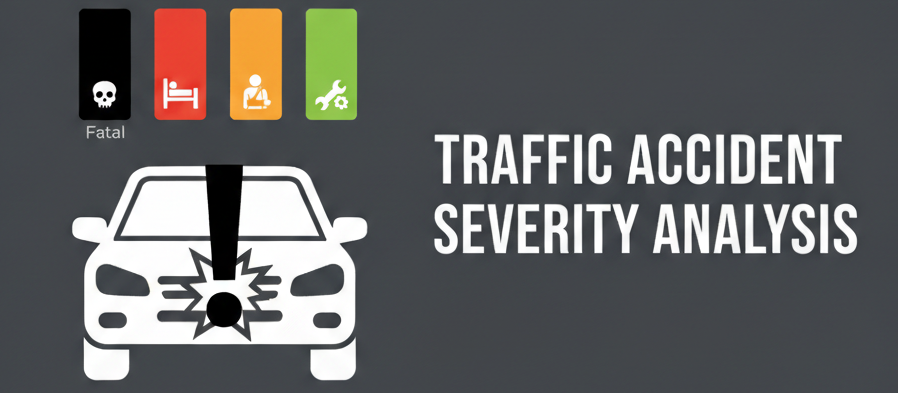

# Analyzing Traffic Accident Severity in the U.S.
#### (Using US Accidents dataset 2016-2023)

## 1. Overview  
  
This project analyzes U.S. traffic accident data to identify factors influencing accident severity. The study focuses on the correlation between road condition, time, and infrastructure to mitigate large-scale traffic disruptions.

## 2. Business Understanding - Segmented Strategies for Regional Traffic Impacts  

The goal of this project is to find the main factors that affect **incident severity (Level 1–4)** and cause traffic delays. By looking at time, road features, and weather data, we aim to create a better traffic management plan. Instead of using the same rules everywhere, this project helps set up a system that fits the specific needs and traffic patterns of different regions.

**Key Deliverables**
* **Risk Identification:** Finding specific times and places where traffic incidents are most likely to happen.
* **Infrastructure Assessment:** Checking how different road types and weather conditions lead to different levels of traffic disruption.
* **Operational Optimization:** Suggesting different response plans—such as early warnings for big delays and fast cleanup for smaller ones—to make traffic management more efficient.
* **Economic Impact Reduction:** Reducing the costs caused by traffic jams by helping officials put resources in the right places based on regional data.

**Methodology**
* **Phase 1 (Sample-based Exploration)**
    * Performing a basic analysis to see the general patterns of **incident severity** and how weather and time affect traffic on a national scale.
* **Phase 2 (Full-scale Modeling)**
    * Using the full dataset to study how weather triggers and road types change the **incident frequency** and impact in different states and cities.
    * Creating final recommendations based on the different traffic problems found in each specific region.

## [Phase 1] Exploratory Analysis (Sample-base)  

## 3. Data Understanding (Initial Inspection & Sampling)

This is a countrywide car accident dataset that covers 49 states of the USA. The accident data were collected from February 2016 to March 2023, using multiple APIs that provide streaming traffic incident (or event) data. 

### 3.1 Data Loading & Schema Verification Strategy  
The dataset is examined to verify integrity and identify patterns across severity levels. Statistical profiling is used to find factors that distinguish minor incidents from major accidents.

In [12]:
import pandas as pd
import numpy as np
import sys

In [13]:
# File path
file_path = "Data/US_Accidents_March23.csv"

In [14]:
# Preliminary Analysis (Dataset is over 3GB)
preview_size = 10000
df_check = pd.read_csv(file_path, nrows=preview_size)

print(f"== Schema Discovery (first {preview_size} rows) ==")
for col in df_check.columns:
    unique_count = df_check[col].nunique()
    total_count = len(df_check[col])
    dtype = df_check[col].dtype

    # If unique values are less than 5% of total rows, it's a candidate for 'category'
    is_candidate = "Candidate for Category" if (unique_count / total_count) < 0.05 else ""
    print(f"Column: {col:<25} | Dtype: {str(dtype):<15} | Unique: {unique_count:<6} {is_candidate}")

== Schema Discovery (first 10000 rows) ==
Column: ID                        | Dtype: object          | Unique: 10000  
Column: Source                    | Dtype: object          | Unique: 2      Candidate for Category
Column: Severity                  | Dtype: int64           | Unique: 4      Candidate for Category
Column: Start_Time                | Dtype: object          | Unique: 9907   
Column: End_Time                  | Dtype: object          | Unique: 9921   
Column: Start_Lat                 | Dtype: float64         | Unique: 6372   
Column: Start_Lng                 | Dtype: float64         | Unique: 6277   
Column: End_Lat                   | Dtype: float64         | Unique: 0      Candidate for Category
Column: End_Lng                   | Dtype: float64         | Unique: 0      Candidate for Category
Column: Distance(mi)              | Dtype: float64         | Unique: 45     Candidate for Category
Column: Description               | Dtype: object          | Unique: 8528   
C

In [15]:
# Memory-Safe Chunked Sampling
'''Chunks allows to monitor the process and handle potential 'Mixed Type' warnings'''
chunk_size = 100000
sample_list = []
total_rows_processed = 0
sample_rate = 0.10

print("=== Starting Chunk-based Sampling ===")

try: 
    for chunk in pd.read_csv(file_path, chunksize=chunk_size, low_memory=False):
        sampled_chunk = chunk.sample(frac=sample_rate, random_state=42)
        sample_list.append(sampled_chunk)
        total_rows_processed += len(chunk)

        if total_rows_processed % 1000000 == 0:
            print(f"Processed {total_rows_processed} rows...")

        df = pd.concat(sample_list, axis=0)
        print(f"\nSampling Complete. Total Rows Sampled: {len(df)}")

except Exception as e:
    print(f"Error during processing: {e}")

=== Starting Chunk-based Sampling ===

Sampling Complete. Total Rows Sampled: 10000

Sampling Complete. Total Rows Sampled: 20000

Sampling Complete. Total Rows Sampled: 30000

Sampling Complete. Total Rows Sampled: 40000

Sampling Complete. Total Rows Sampled: 50000

Sampling Complete. Total Rows Sampled: 60000

Sampling Complete. Total Rows Sampled: 70000

Sampling Complete. Total Rows Sampled: 80000

Sampling Complete. Total Rows Sampled: 90000
Processed 1000000 rows...

Sampling Complete. Total Rows Sampled: 100000

Sampling Complete. Total Rows Sampled: 110000

Sampling Complete. Total Rows Sampled: 120000

Sampling Complete. Total Rows Sampled: 130000

Sampling Complete. Total Rows Sampled: 140000

Sampling Complete. Total Rows Sampled: 150000

Sampling Complete. Total Rows Sampled: 160000

Sampling Complete. Total Rows Sampled: 170000

Sampling Complete. Total Rows Sampled: 180000

Sampling Complete. Total Rows Sampled: 190000
Processed 2000000 rows...

Sampling Complete. Total 

In [16]:
# Summary of Column Health
'''Identify which columns are relaible and which need significant cleaning.'''
health_report = pd.DataFrame({'Dtype': df.dtypes,
                              'Null_Count': df.isnull().sum(),
                              'Null_Percentage': (df.isnull().sum() / len(df)) * 100,
                              'Unique_Values': df.nunique()})

# Sort
print("=== Column Health Report (Top 20) ===")
print(health_report.sort_values(by='Null_Percentage', ascending=False).head(20))

# Overall completeness
total_cells = np.prod(df.shape)
total_nulls = df.isnull().sum().sum()
print(f"\n=== Overall Data Quality Summary ===")
print(f"Total Rows: {len(df)}")
print(f"Total Missing Values: {total_nulls} ({ (total_nulls/total_cells)*100:.2f}% of total data)")
print(f"Columns with > 50% Missing: {len(health_report[health_report['Null_Percentage'] > 50])}")

=== Column Health Report (Top 20) ===
                         Dtype  Null_Count  Null_Percentage  Unique_Values
End_Lat                float64      340298        44.032198         316661
End_Lng                float64      340298        44.032198         318839
Precipitation(in)      float64      221061        28.603758            187
Wind_Chill(F)          float64      200187        25.902808            835
Wind_Speed(mph)        float64       57526         7.443465            112
Visibility(mi)         float64       17950         2.322605             61
Wind_Direction          object       17819         2.305655             24
Humidity(%)            float64       17588         2.275765            100
Weather_Condition       object       17550         2.270848            117
Temperature(F)         float64       16559         2.142620            752
Pressure(in)           float64       14314         1.852132           1022
Weather_Timestamp       object       12212         1.580148   

### 3.2 Numerical & Target Distribution

In [18]:
# Numerical Feature Distribution & Outliers
'''Weather and physical impact metrics.'''
print("=== Detailed Statistics for Key Numerical Columns ===")
key_num_cols = ['Severity', 'Distance(mi)', 'Temperature(F)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']

# Checking percentiles
stats = df[key_num_cols].describe(percentiles=[.01, .25, .5, .75, .99])
print(stats)

=== Detailed Statistics for Key Numerical Columns ===
            Severity   Distance(mi)  Temperature(F)  Visibility(mi)  \
count  772839.000000  772839.000000   756280.000000   754889.000000   
mean        2.212731       0.560512       61.683076        9.093305   
std         0.488106       1.737856       18.985987        2.690374   
min         1.000000       0.000000      -89.000000        0.000000   
1%          2.000000       0.000000       12.900000        0.500000   
25%         2.000000       0.000000       49.000000       10.000000   
50%         2.000000       0.030000       64.000000       10.000000   
75%         2.000000       0.465000       76.000000       10.000000   
99%         4.000000       6.910000       96.000000       10.000000   
max         4.000000     149.690000      196.000000      100.000000   

       Wind_Speed(mph)  Precipitation(in)  
count    715313.000000      551778.000000  
mean          7.685036           0.008221  
std           5.576693          

In [19]:
# Target Variable (Severity)
print("=== Severity Distribution (Target Variable) ===")
severity_counts = df['Severity'].value_counts().sort_index()
severity_pct = df['Severity'].value_counts(normalize=True).sort_index() *100

severity_report = pd.DataFrame({'Count': severity_counts,
                                'Percentage (%)': severity_pct})
print(severity_report)

=== Severity Distribution (Target Variable) ===
           Count  Percentage (%)
Severity                        
1           6757        0.874309
2         615508       79.642461
3         129984       16.819027
4          20590        2.664203


In [20]:
# Categorical Dominance (Top values)
print("=== Top 5 States and Weather Conditions ===")
print("Top States:\n", df['State'].value_counts().head(5))
print("\nTop Weather Conditions:\n", df['Weather_Condition'].value_counts().head(5))

=== Top 5 States and Weather Conditions ===
Top States:
 State
CA    174744
FL     87871
TX     58147
SC     38409
NY     34747
Name: count, dtype: int64

Top Weather Conditions:
 Weather_Condition
Fair             256560
Mostly Cloudy    101261
Cloudy            81702
Clear             81006
Partly Cloudy     69687
Name: count, dtype: int64


### 3.3 Severity-Segmented Analysis

In [22]:
# Comparison of Numerical Features by Severity
print("=== Average Values by Severity Level ===")
'''Logical influences'''
comparison_cols = ['Distance(mi)', 'Temperature(F)', 'Visibility(mi)', 'Precipitation(in)']
severity_group_num = df.groupby('Severity')[comparison_cols].mean()
print(severity_group_num)

=== Average Values by Severity Level ===
          Distance(mi)  Temperature(F)  Visibility(mi)  Precipitation(in)
Severity                                                                 
1             0.106166       72.264162        9.469130           0.004633
2             0.561549       61.586507        9.086852           0.006987
3             0.423562       62.151764        9.106537           0.017194
4             1.543170       58.082681        9.078400           0.008855


In [23]:
# Road Feature Impact (POI) by Severity
poi_cols = ['Junction', 'Traffic_Signal', 'Crossing', 'Stop', 'Station', 'Railway']
print("=== Road Feature Frequency by Severity (%) ===")
severity_group_poi = df.groupby('Severity')[poi_cols].mean() * 100
print(severity_group_poi)

=== Road Feature Frequency by Severity (%) ===
           Junction  Traffic_Signal   Crossing      Stop   Station   Railway
Severity                                                                    
1          4.632233       38.656208  27.408613  3.611070  3.729466  1.524345
2          6.784640       16.332038  12.848086  3.201096  2.998174  0.896333
3         10.303576        6.787758   3.679684  0.560838  0.950117  0.687008
4         10.029140        9.912579   6.464303  2.778048  1.306459  0.830500


## 4. Data Preparation (Sample)
Data is cleaned by removing outliers and adding time variables. This process ensures each severity level is represented accurately by filtering out errors.

### 4.1 Physical Outlier Cleaning

In [26]:
# By US meteorological limits and logical thresholds
print("=== Cleaning Outliers ===")
initial_len = len(df)
df = df[(df['Wind_Speed(mph)'] <= 150) &
        (df['Temperature(F)'] >= -50) &
        (df['Temperature(F)'] <= 130) &
        (df['Visibility(mi)'] <=50)]
print(f"Removed {initial_len - len(df)} rows containing phyiscal outliers.")

=== Cleaning Outliers ===
Removed 62360 rows containing phyiscal outliers.


### 4.2 DateTime Convert

In [28]:
# Convert string to datetime and extracting features for periodic analysis
df = df.copy()

df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df = df.dropna(subset=['Start_Time'])

df['Hour'] = df['Start_Time'].dt.hour
df['Weekday'] = df['Start_Time'].dt.weekday # 0=Monday, 6=Sunday
df['Month'] = df['Start_Time'].dt.month

### 4.3 Missing Values

In [30]:
# Precipiation NaN is highly likely to be 0 (no rain recorded)
df['Precipiation(in)'] = df['Precipitation(in)'].fillna(0)

In [31]:
# Categorical weather, fill 'unknown' instead of dropping
'''Maintain the sample size for Severity 4'''
df['Weather_Condition'] = df['Weather_Condition'].fillna('Unknown')

### 4.4 Drop Redundant Columns (Unique value = 1)

In [33]:
cols_to_drop = ['Country', 'Turning_Loop']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

### 4.5 Preview after data preparation  
Final data dimension and memory efficiency are verified to ensure the dataset is optimized for analysis. The preview of time-based variables confirms that features for hourly, weekly, and monthly are correctly extracted.

In [35]:
# Final check
print(f"=== Final cleaned dataset size: {df.shape}")
print(f"Remaining memory usage: {df.memory_usage().sum() / (1024**2):.2f} MB")

# Preview the features
print("\n=== Sample of Features ===")
print(df[['Severity', 'Hour', 'Weekday', 'Month']].head(20))

=== Final cleaned dataset size: (638857, 48)
Remaining memory usage: 180.34 MB

=== Sample of Features ===
       Severity  Hour  Weekday  Month
80184         3    12        2      9
19864         3    20        1      9
92991         3    17        5      8
84004         3    16        4     10
80917         3    14        5     10
50074         3    13        2      7
27701         3    23        2      8
42141         3     5        0      6
45080         3    18        1      6
20424         2     1        4      9
88702         2    18        3      8
149           2     7        0      2
63120         2    17        0      1
64883         3    12        0      1
2495          2    11        4      7
80296         3    20        2      9
19447         2    12        2     11
41331         3    12        0      6
88636         2    15        3      8
94892         3    20        4      9


## 5. Analysis (Sample-based EDA)

Definition of Severity: Accident severity is measured by its impact of traffic flow on a scale of 1 to 4
- Severity 1: Minor impact on traffic with minimal delays
- Severity 2: Partial lane closure with moderate delays
- Severity 3: Significant lane blockage causing extensive traffic congestion
- Severity 4: Complete road closure or major incident leading to severe traffic distuption

Data Source: Unified traffic data form the U.S. Department of Transporation (DOT) and National Weather Service (NWS)

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

### 5.1 Hourly Distribution by Severity

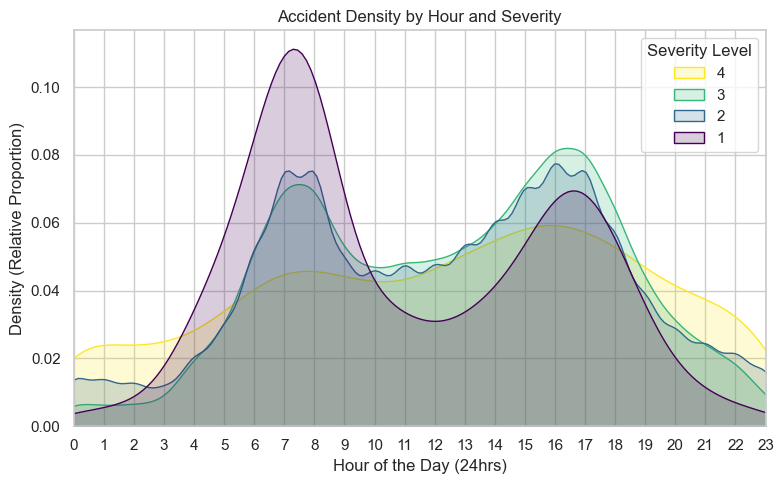

In [39]:
plt.figure(figsize=(8,5))
sns.set_theme(style='whitegrid')

# Compare hourly density
sns.kdeplot(data=df, x='Hour', hue='Severity', palette='viridis',
            common_norm=False, fill=True, alpha=0.2, bw_adjust=1.2)

plt.title('Accident Density by Hour and Severity')
plt.xlabel('Hour of the Day (24hrs)')
plt.ylabel('Density (Relative Proportion)')
plt.xticks(range(0, 24))
plt.xlim(0, 23)

plt.legend(title='Severity Level', labels=['4', '3', '2', '1'])
plt.tight_layout()
plt.show()

In [40]:
# Table
def get_time_period(hour):
    if 0 <= hour < 6: return 'Late Night (00-06)'
    elif 6 <= hour < 10: return 'Morning Rush (06-10)'
    elif 10 <= hour < 16: return 'Mid-Day (10-16)'
    elif 16 <= hour < 20: return 'Evening Rush (16-20)'
    else: return 'Night (20-24)'

df['Time_Period'] = df['Hour'].apply(get_time_period)
severity_time_table = pd.crosstab(df['Time_Period'], df['Severity'], normalize='columns') * 100
print('=== Percentage Distribution of Accidents by Time Period ===')
print(severity_time_table)

=== Percentage Distribution of Accidents by Time Period ===
Severity                      1          2          3          4
Time_Period                                                     
Evening Rush (16-20)  24.710895  24.449276  27.294718  22.046859
Late Night (00-06)    11.031649  10.059800   7.383939  16.321037
Mid-Day (10-16)       21.545953  31.697417  32.366629  29.357069
Morning Rush (06-10)  39.196592  24.845219  24.737290  17.972717
Night (20-24)          3.514912   8.948288   8.217425  14.302318


**Comment**  
Severity 4 accidents show a distinct trend, with significantly higher proportions during Night and Late Night hours (20:00-06:00) compared to other levels. In contrast, Severity 1 incidents are heavily concentrated during the Morning Rush, suggsting that lower speeds during peak hours may limit accident severity despite higher frequency.

### 5.2 Road Features (POI)

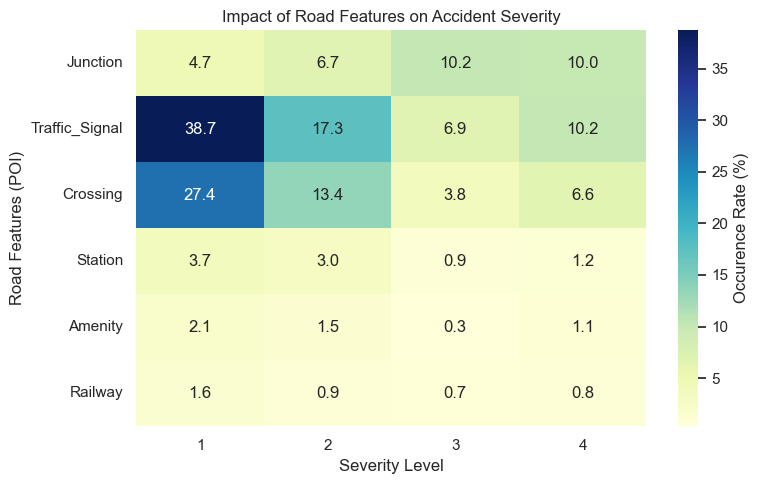

=== Road Feature Occurence Rate (%) by Severity ===
Severity            1      2      3      4
Junction         4.67   6.75  10.19   9.97
Traffic_Signal  38.71  17.31   6.92  10.17
Crossing        27.45  13.42   3.77   6.63
Station          3.67   3.05   0.93   1.22
Amenity          2.07   1.47   0.34   1.08
Railway          1.55   0.91   0.66   0.81


In [43]:
# Key inftrastucture features
poi_features = ['Junction', 'Traffic_Signal', 'Crossing', 'Station', 'Amenity', 'Railway']

# Calculate the percentage of 'True' values for each feature per Severity level
poi_analysis = df.groupby('Severity')[poi_features].mean() * 100

# Visualize
plt.figure(figsize=(8,5))
sns.heatmap(poi_analysis.T, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': 'Occurence Rate (%)'})

plt.title('Impact of Road Features on Accident Severity')
plt.xlabel('Severity Level')
plt.ylabel('Road Features (POI)')
plt.tight_layout()
plt.show()

# Table
print("=== Road Feature Occurence Rate (%) by Severity ===")
print(poi_analysis.T.round(2))

**Comment**  
Traffic Signals and Crossings are hotspots for Severity 1, whereas Junctions are critical triggers for Severity 3 and 4. This indicates that while urban stops cause frequent small accidents, high-speed merging points are the primary cause of total traffic paralysis.

### 5.3 Weather & Environmental Analysis

In [46]:
# Key weather metrics
weather_metrics = ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Precipiation(in)']
weather_analysis = df.groupby('Severity')[weather_metrics].mean()

print("=== Average Weather Metrics ===")
print(weather_analysis.round(2))

=== Average Weather Metrics ===
          Temperature(F)  Humidity(%)  Visibility(mi)  Precipiation(in)
Severity                                                               
1                  72.28        62.62            9.46              0.00
2                  61.75        64.47            9.10              0.01
3                  62.51        64.72            9.11              0.01
4                  58.46        66.44            9.10              0.01


**Comment**  
Severity 4 incidents correlate with lower temperatures and higher humidity, often reflecting hazardous night-time or damp conditions. Coversely, Severity 1 accidents peak with in warmer, drier weather, typical of daylight commuting hours.

### 5.4 Spatial Analysis (Top 10 States)

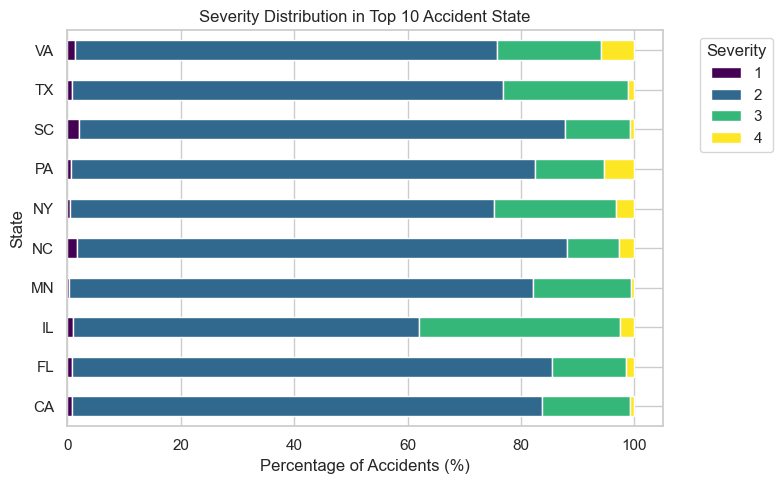

Severity     1      2      3     4
State                             
CA        0.74  82.90  15.64  0.71
FL        0.87  84.56  13.03  1.54
IL        1.00  60.95  35.44  2.61
MN        0.36  81.70  17.41  0.53
NC        1.75  86.34   9.27  2.64
NY        0.41  74.78  21.61  3.20
PA        0.67  81.82  12.07  5.45
SC        2.01  85.82  11.40  0.76
TX        0.84  76.01  21.96  1.19
VA        1.38  74.36  18.28  5.98


In [49]:
# Top 10 states
top_10_states = df['State'].value_counts().nlargest(10).index
df_top_states = df[df['State'].isin(top_10_states)]

# Cross-tabulation: State and Severity
state_severity = pd.crosstab(df_top_states['State'], df_top_states['Severity'], normalize='index') * 100

# Visualzie
state_severity.plot(kind='barh', stacked=True, figsize=(8,5), colormap='viridis')
plt.title('Severity Distribution in Top 10 Accident State')
plt.xlabel('Percentage of Accidents (%)')
plt.ylabel('State')
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Table
print(state_severity.round(2))

**Comment**  
Spatial analysis reveals that while CA and FL have the highest accident frequency, they are dominated by low_severity incidents. In contrast, VA and PA exhibit a significaltly higer risk of Severity 4, indicating that regional infrastructure or environmental factors in these states lead to more catastrophic traffic disruptions.

### 5.5 Integrated Insight Dashboard (Final Summary)

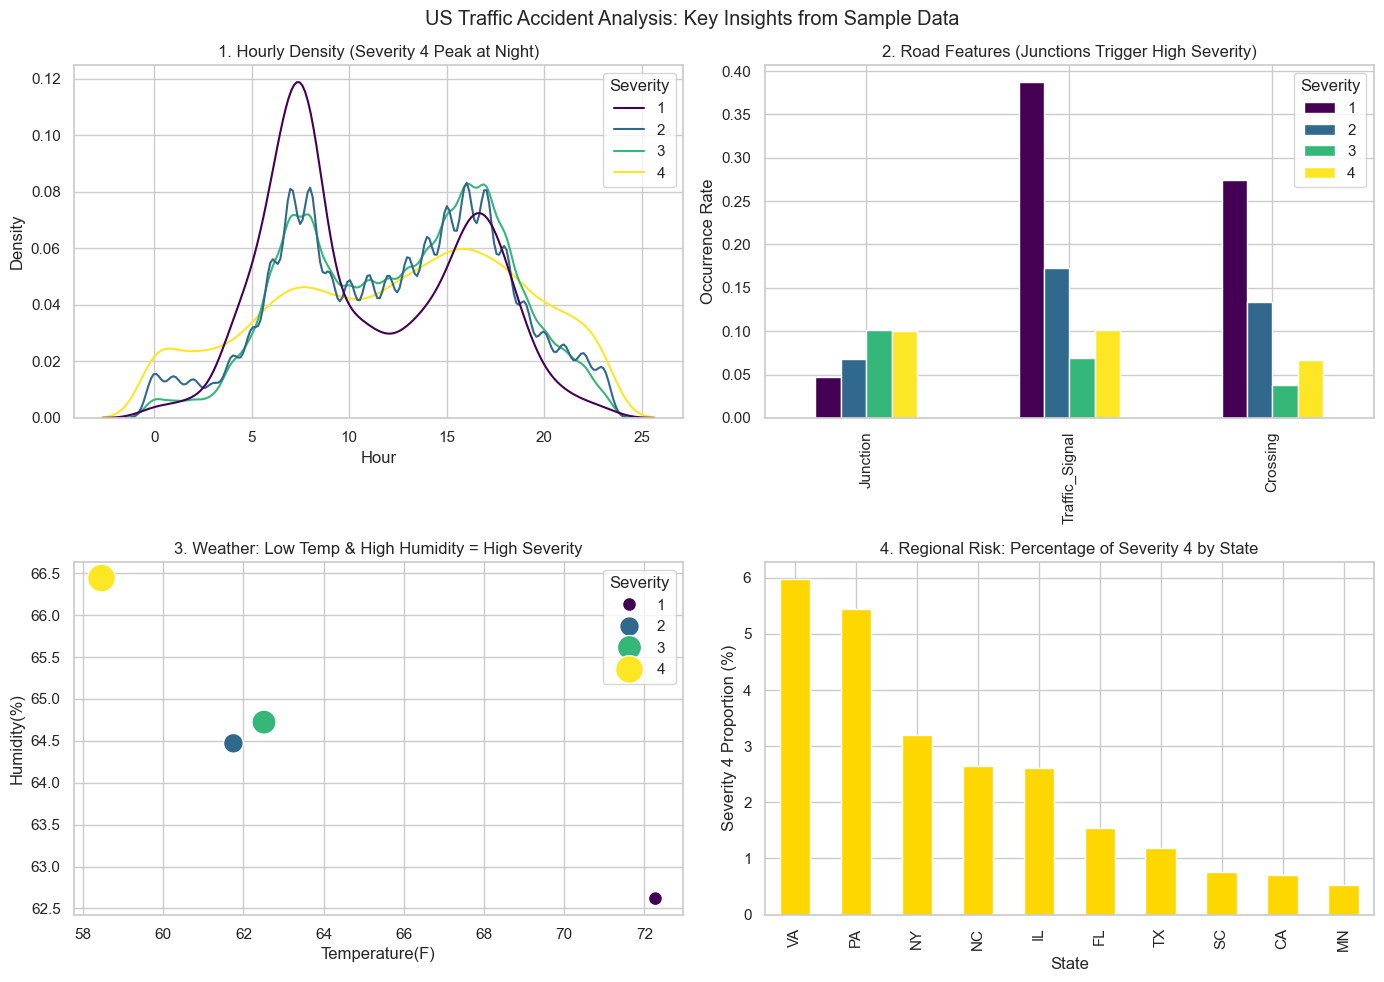

In [52]:
# Set the visualization layout
fig, axes = plt.subplots(2, 2, figsize=(14,10))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# Temporal: Severity 4 vs Others (Density)
sns.kdeplot(data=df, x='Hour', hue='Severity', common_norm=False, palette='viridis', ax=axes[0,0])
axes[0,0].set_title('1. Hourly Density (Severity 4 Peak at Night)')

# Infrastructure: Top Critical Features (Junction & Signal)
poi_summary = df.groupby('Severity')[['Junction', 'Traffic_Signal', 'Crossing']].mean().T
poi_summary.plot(kind='bar', ax=axes[0,1], colormap='viridis')
axes[0,1].set_title('2. Road Features (Junctions Trigger High Severity)')
axes[0,1].set_ylabel('Occurrence Rate')

# Environmental: Temperature & Humidity Trend
sns.scatterplot(data=weather_analysis, x='Temperature(F)', y='Humidity(%)', 
                hue='Severity', size='Severity', sizes=(100, 400), palette='viridis', ax=axes[1,0])
axes[1,0].set_title('3. Weather: Low Temp & High Humidity = High Severity')

# Spatial: Severity 4 Risk by State
state_severity[4].sort_values(ascending=False).plot(kind='bar', color='gold', ax=axes[1,1])
axes[1,1].set_title('4. Regional Risk: Percentage of Severity 4 by State')
axes[1,1].set_ylabel('Severity 4 Proportion (%)')

plt.suptitle('US Traffic Accident Analysis: Key Insights from Sample Data')
plt.tight_layout()
plt.show()

## [Phase 2] Full-scale Modeling (Enire Dataset)

## 6. Large-scale Data Preparation

### 6.1 Chunk-based Loading  

Memory Managent Startegy: To overcome the hardware limitation of 8GB RAM (Apple M3), a chunk-base loading strategy was implemented.
- Instead of loading the entire 9.7GB dataset at once, the data was processed in segments (500,000 rows each) and downcast to optimized numeric types.
- This approach succesfully reduced the memory footprint by approxiamately 96% (to 368.52MB), ensuring system statbility and computational efficiency.

In [198]:
import pandas as pd
import numpy as np
import gc

In [400]:
# Define configuration
file_path = 'Data/US_Accidents_March23.csv'
use_cols = ['Severity', 'Start_Time', 'Temperature(F)', 'Humidity(%)', 'Visibility(mi)',
            'Wind_Speed(mph)', 'Precipitation(in)', 'Amenity', 'Bump', 'Crossing',
            'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
            'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'State', 'City', 'County']
bool_cols = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
             'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop']
dtype_dict = {col: 'bool' for col in bool_cols}

In [404]:
# Chunk-base processing
chunk_size = 500000
chunk_list = []

print("Staring chunk-based loading...")

try:
    for chunk in pd.read_csv(file_path, usecols=use_cols, dtype=dtype_dict, chunksize=chunk_size, low_memory=False):
        for col in chunk.select_dtypes(include=['float64']).columns:
            chunk[col] = pd.to_numeric(chunk[col], downcast='float')
        for col in chunk.select_dtypes(include=['int64']).columns:
            chunk[col] = pd.to_numeric(chunk[col], downcast='integer')

        for col in ['State', 'City', 'County']:
            if col in chunk.columns:
                chunk[col] = chunk[col].astype('category')
        
        chunk_list.append(chunk)
        print(f"Processed {len(chunk_list) * chunk_size:,} rows...")

    # Concatenate all optimized chunks
    df_full = pd.concat(chunk_list, ignore_index=True)

    # Clean up memory
    del chunk_list
    gc.collect()

    print("\nSucessfully loaded")
    print(f"Final Memody Usage: {df_full.memory_usage().sum() / 1024**2:.2f} MB")

except Exception as e:
    print(f"Error during loading: {e}")

Staring chunk-based loading...
Processed 500,000 rows...
Processed 1,000,000 rows...
Processed 1,500,000 rows...
Processed 2,000,000 rows...
Processed 2,500,000 rows...
Processed 3,000,000 rows...
Processed 3,500,000 rows...
Processed 4,000,000 rows...
Processed 4,500,000 rows...
Processed 5,000,000 rows...
Processed 5,500,000 rows...
Processed 6,000,000 rows...
Processed 6,500,000 rows...
Processed 7,000,000 rows...
Processed 7,500,000 rows...
Processed 8,000,000 rows...

Sucessfully loaded
Final Memody Usage: 486.44 MB


In [408]:
# Check basic info and null values
print(df_full.info())
print("\nMissing values per column:")
print(df_full.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 23 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Severity           int8   
 1   Start_Time         object 
 2   City               object 
 3   County             object 
 4   State              object 
 5   Temperature(F)     float32
 6   Humidity(%)        float32
 7   Visibility(mi)     float32
 8   Wind_Speed(mph)    float32
 9   Precipitation(in)  float32
 10  Amenity            bool   
 11  Bump               bool   
 12  Crossing           bool   
 13  Give_Way           bool   
 14  Junction           bool   
 15  No_Exit            bool   
 16  Railway            bool   
 17  Roundabout         bool   
 18  Station            bool   
 19  Stop               bool   
 20  Traffic_Calming    bool   
 21  Traffic_Signal     bool   
 22  Turning_Loop       bool   
dtypes: bool(13), float32(5), int8(1), object(4)
memory usage: 486.4+ MB
None

Missing 

In [410]:
# Statistical summary
print(df_full.describe())

           Severity  Temperature(F)   Humidity(%)  Visibility(mi)  \
count  7.728394e+06    7.564541e+06  7.554250e+06    7.551296e+06   
mean   2.212384e+00    6.166327e+01  6.483102e+01    9.090382e+00   
std    4.875313e-01    1.893420e+01  2.275716e+01    2.834052e+00   
min    1.000000e+00   -8.900000e+01  1.000000e+00    0.000000e+00   
25%    2.000000e+00    4.900000e+01  4.800000e+01    1.000000e+01   
50%    2.000000e+00    6.400000e+01  6.700000e+01    1.000000e+01   
75%    2.000000e+00    7.600000e+01  8.400000e+01    1.000000e+01   
max    4.000000e+00    2.070000e+02  1.000000e+02    1.400000e+02   

       Wind_Speed(mph)  Precipitation(in)  
count     7.157161e+06       5.524808e+06  
mean      7.685489e+00       8.407203e-03  
std       5.357770e+00       1.098795e-01  
min       0.000000e+00       0.000000e+00  
25%       4.600000e+00       0.000000e+00  
50%       7.000000e+00       0.000000e+00  
75%       1.040000e+01       0.000000e+00  
max       1.087000e+03    

In [412]:
# Spatial coverage check
print(f"Unique States: {df_full['State'].nunique()}")
print(f"Unique Cities: {df_full['City'].nunique()}")

Unique States: 49
Unique Cities: 13678


### 6.2 Entire Data Cleaning

In [414]:
# Convert 'Start_Time' to datetime
df_full['Start_Time'] = pd.to_datetime(df_full['Start_Time'], errors = 'coerce')

In [416]:
# Check missing values
print("Missing values per column:")
print(df_full.isnull().sum())

Missing values per column:
Severity                   0
Start_Time            743166
City                     253
County                     0
State                      0
Temperature(F)        163853
Humidity(%)           174144
Visibility(mi)        177098
Wind_Speed(mph)       571233
Precipitation(in)    2203586
Amenity                    0
Bump                       0
Crossing                   0
Give_Way                   0
Junction                   0
No_Exit                    0
Railway                    0
Roundabout                 0
Station                    0
Stop                       0
Traffic_Calming            0
Traffic_Signal             0
Turning_Loop               0
dtype: int64


In [445]:
# Handle critical missing values
''''Start_Time' is essential for temporal analysis. Rows without it unsusable.'''
df_full = df_full.dropna(subset=['Start_Time'])

# City and County Handling
df_full = df_full.dropna(subset=['City'])

# Refined Imputation for Weather features
'''Using median for skewed weather data (Temperature, Humidity, Visibility, Wind_Speed)'''
weather_to_median = ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)']
for col in weather_to_median:
    df_full[col] = df_full[col].fillna(df_full[col].median())

# Basic outlier clipping
'''Removing extreme sensor errors'''
df_full = df_full[df_full['Wind_Speed(mph)'] <= 200]
df_full = df_full[df_full['Temperature(F)'] <= 150]

# Specific Handling for Precipitation(in)
'''Missing precipitation means, no rain'''
df_full['Precipitation(in)'] = df_full['Precipitation(in)'].fillna(0.0)

In [451]:
# Final verification
print("Missing values after strategic cleaning:")
print(df_full.isnull().sum())
print(f"Final Rows retained: {len(df_full):,}")
gc.collect()

Missing values after strategic cleaning:
Severity             0
Start_Time           0
City                 0
County               0
State                0
Temperature(F)       0
Humidity(%)          0
Visibility(mi)       0
Wind_Speed(mph)      0
Precipitation(in)    0
Amenity              0
Bump                 0
Crossing             0
Give_Way             0
Junction             0
No_Exit              0
Railway              0
Roundabout           0
Station              0
Stop                 0
Traffic_Calming      0
Traffic_Signal       0
Turning_Loop         0
dtype: int64
Final Rows retained: 6,984,949


674

### 6.3 Temporal Feature Extraction

In [453]:
# Extract temporal features
df_full['Hour'] = df_full['Start_Time'].dt.hour.astype('int8')
df_full['DayOfWeek'] = df_full['Start_Time'].dt.dayofweek.astype('int8')
df_full['Month'] = df_full['Start_Time'].dt.month.astype('int8')
df_full['Year'] = df_full['Start_Time'].dt.year.astype('int16')

# To save memory
df_full['Date'] = df_full['Start_Time'].dt.date.astype('category')

In [455]:
# Categorize Time of Day
def get_time_period(hour):
    if 0 <= hour < 6: return 'Late Night (00-06)'
    elif 6 <= hour < 10: return 'Morning Rush (06-10)'
    elif 10 <= hour < 16: return 'Mid-Day (10-16)'
    elif 16 <= hour < 20: return 'Evening Rush (16-20)'
    else: return 'Night (20-24)'

df_full['Time_Period'] = df_full['Hour'].apply(get_time_period)

In [457]:
# Drop original Start_Time
'''Memory management'''
df_full = df_full.drop('Start_Time', axis=1)

In [459]:
# Final verification
print("Accident distribution by 5 periods:")
print(df_full['Time_Period'].value_counts().sort_index())

# Check memory
print(f"\nFinal Memory Usage: {df_full.memory_usage().sum() / 1024**2:.2f} MB")
gc.collect()

Accident distribution by 5 periods:
Time_Period
Evening Rush (16-20)    1694408
Late Night (00-06)       699423
Mid-Day (10-16)         2163116
Morning Rush (06-10)    1797603
Night (20-24)            630399
Name: count, dtype: int64

Final Memory Usage: 539.65 MB


3801

### 6.4 Categorical Encoding

In [463]:
# Identify categorical columns
cat_cols = ['Time_Period', 'State', 'City', 'County']

# Apply category dtype for memory efficiency and label preservation
for col in cat_cols:
    if col in df_full.columns:
        df_full[col] = df_full[col].astype('category')
        print(f"Converted {col} to category. Unique values: {df_full[col].nunique()}")

# Final check of data types and memory
print("\nFinal Data Types:")
print(df_full.dtypes)

# Memory check
print(f"\nFinal Memory Usage: {df_full.memory_usage().sum() / 1024**2:.2f} MB")
gc.collect()

Converted Time_Period to category. Unique values: 5
Converted State to category. Unique values: 49
Converted City to category. Unique values: 13600
Converted County to category. Unique values: 1868

Final Data Types:
Severity                 int8
City                 category
County               category
State                category
Temperature(F)        float32
Humidity(%)           float32
Visibility(mi)        float32
Wind_Speed(mph)       float32
Precipitation(in)     float32
Amenity                  bool
Bump                     bool
Crossing                 bool
Give_Way                 bool
Junction                 bool
No_Exit                  bool
Railway                  bool
Roundabout               bool
Station                  bool
Stop                     bool
Traffic_Calming          bool
Traffic_Signal           bool
Turning_Loop             bool
Hour                     int8
DayOfWeek                int8
Month                    int8
Year                    int16
Dat

674

## 7. Severity-Driven Risk Factor Deep Dive & Strategic Profiling

### 7.1 Temporal & Infrastructure Severity Analysis

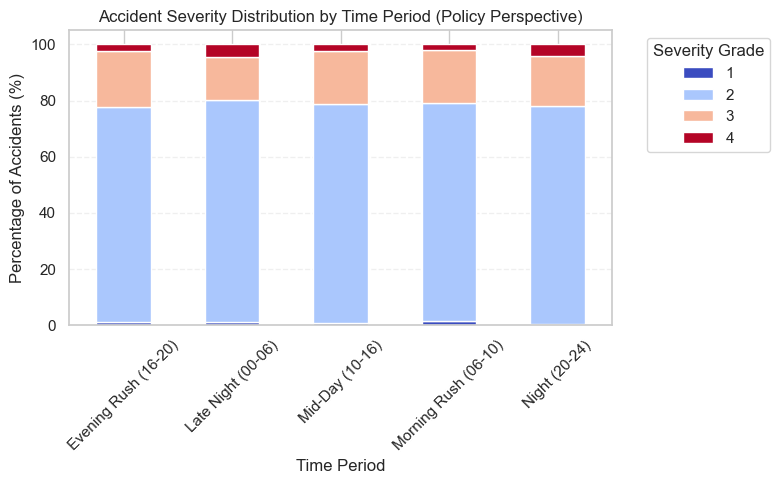

=== Risk Profile: Probability of Severity 4 by Infrastructure (%) ===
Junction       : 3.65%
Stop           : 2.60%
Railway        : 2.28%
Amenity        : 2.15%
Traffic_Signal : 1.69%
Crossing       : 1.54%


6245

In [474]:
# Temporal Severity Analysis: Crossing Time_Period with Severity
time_severity_pct = pd.crosstab(df_full['Time_Period'], df_full['Severity'], normalize='index') * 100

# Infrastructure Risk Profiling: Calculating the probability of Severity 4 for each feature
infra_features = ['Junction', 'Traffic_Signal', 'Crossing', 'Stop', 'Amenity', 'Railway']
severity_4_risks = {}

for feature in infra_features:
    # Calculate the ratio of Severity 4 when the feature is present (True)
    if feature in df_full.columns:
        s4_ratio = df_full[df_full[feature] == True]['Severity'].value_counts(normalize=True).get(4, 0) * 100
        severity_4_risks[feature] = s4_ratio

# Visualize
plt.figure(figsize=(8,5))
time_severity_pct.plot(kind='bar', stacked=True, colormap='coolwarm', ax=plt.gca())
plt.title('Accident Severity Distribution by Time Period (Policy Perspective)')
plt.xlabel('Time Period')
plt.ylabel('Percentage of Accidents (%)')
plt.legend(title='Severity Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Results: High-Impact Infrastructure for Severity 4
print("=== Risk Profile: Probability of Severity 4 by Infrastructure (%) ===")
sorted_risks = sorted(severity_4_risks.items(), key=lambda x: x[1], reverse=True)
for feature, risk in sorted_risks:
    print(f"{feature:15}: {risk:.2f}%")

gc.collect()

**Comment**  
Evaluate the impact of infrastructure types on Severity 4 (Total Road Closure) probability.

Result Interpretation:
- Junctions (3.65%) and Stop signs (2.60%) have the highest likelihood of escalating into S4 incidents.
- These points act as critical nodes where collisions lead to massive regional gridlock.

Strategic Implication:
- Shift infrastructure budget priorities toward junction safety redesign and proactive ITS deployment at high-risk stop-controlled zones to prevent national-scale logistics paralysis.

### 7.2 Spatial Severity Profile

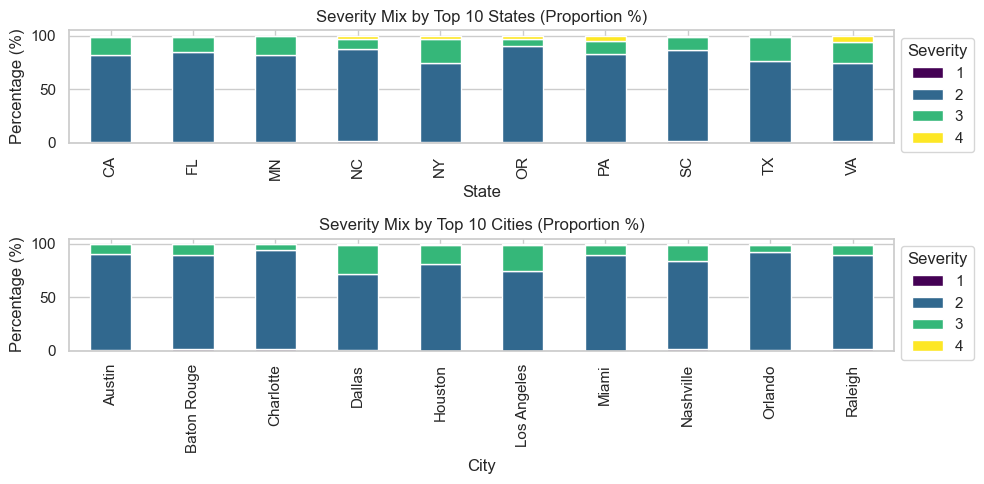

=== [Table] Severity Distribution by Top 10 States (%) ===
Severity         1          2          3         4
State                                             
VA        1.190554  73.324721  19.615277  5.869448
PA        0.662690  82.229870  11.879805  5.227635
OR        0.812634  89.947421   5.975897  3.264048
NY        0.401196  73.794317  22.576550  3.227937
NC        1.658432  85.964482   9.549135  2.827951
FL        0.925172  83.862448  13.592054  1.620325
TX        0.776987  75.899280  22.107684  1.216049
SC        1.759104  85.343745  12.098647  0.798505
CA        0.656241  81.221141  17.340349  0.782269
MN        0.284494  81.870331  17.384981  0.460194

=== [Table] Severity Distribution by Top 10 Cities (%) ===
Severity            1          2          3         4
City                                                 
Miami        0.106042  89.171596   9.358511  1.363851
Orlando      0.829969  91.667201   6.375911  1.126920
Dallas       0.822484  70.950196  27.298202  0.929118

17976

In [487]:
# State-level Severity Composition (Top 10 States by total accident volume)
top_10_states = df_full['State'].value_counts().head(10).index
state_severity_dist = pd.crosstab(df_full[df_full['State'].isin(top_10_states)]['State'], 
                                  df_full['Severity'], normalize='index') * 100

# City-level Severity Composition (Top 10 Cities by total accident volume)
top_10_cities = df_full['City'].value_counts().head(10).index
city_severity_dist = pd.crosstab(df_full[df_full['City'].isin(top_10_cities)]['City'], 
                                 df_full['Severity'], normalize='index') * 100

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(10,5))

# Plot States
state_severity_dist.plot(kind='bar', stacked=True, colormap='viridis', ax=axes[0])
axes[0].set_title('Severity Mix by Top 10 States (Proportion %)')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(title='Severity', bbox_to_anchor=(1.0, 1))

# Plot Cities
city_severity_dist.plot(kind='bar', stacked=True, colormap='viridis', ax=axes[1])
axes[1].set_title('Severity Mix by Top 10 Cities (Proportion %)')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='Severity', bbox_to_anchor=(1.0, 1))

plt.tight_layout()
plt.show()

# Display Tables for detailed audit
print("=== [Table] Severity Distribution by Top 10 States (%) ===")
print(state_severity_dist.sort_values(by=4, ascending=False)) 

print("\n=== [Table] Severity Distribution by Top 10 Cities (%) ===")
print(city_severity_dist.sort_values(by=4, ascending=False))

gc.collect()

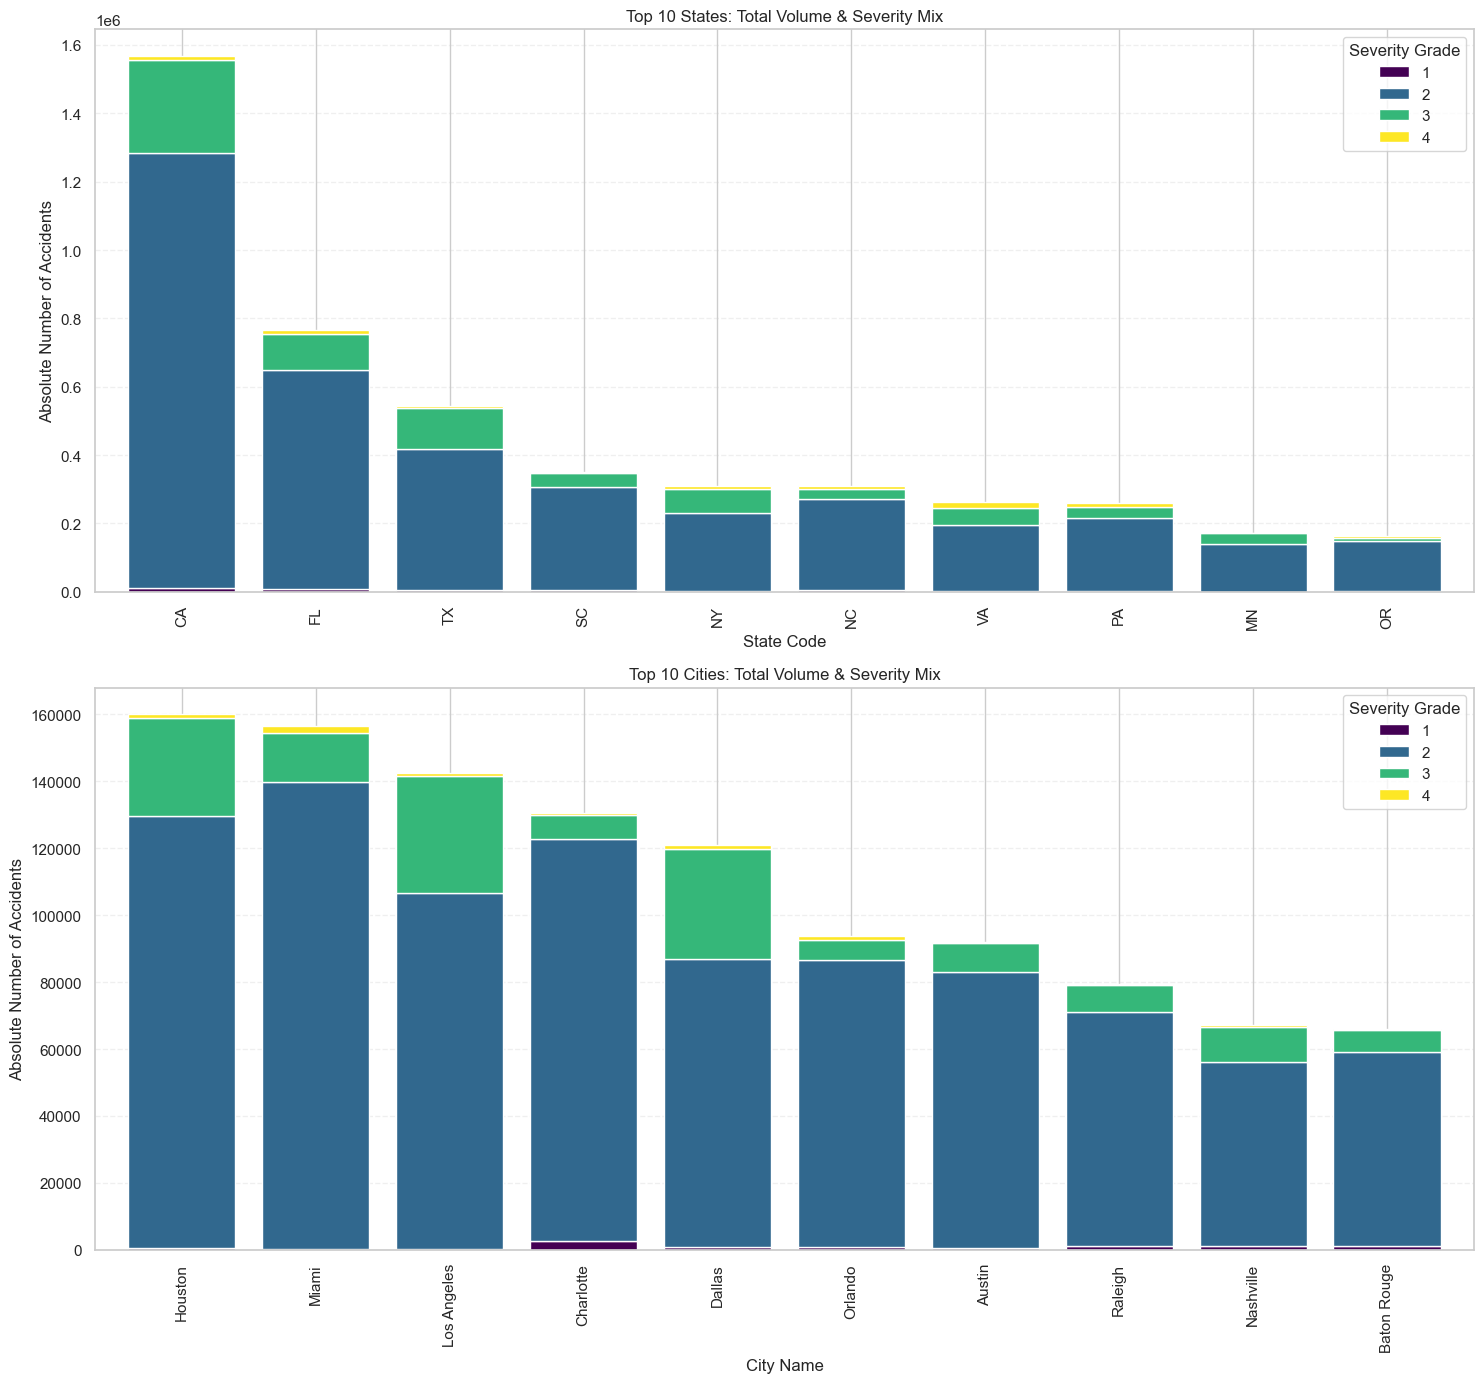

=== Top 10 States Severity Mix (Absolute Counts) ===
Severity      1        2       3      4
State                                  
CA        10284  1272823  271742  12259
FL         7083   642040  104059  12405
TX         4233   413497  120442   6625
SC         6175   299583   42470   2803
NY         1245   229000   70060  10017
NC         5139   266379   29590   8763
VA         3115   191849   51322  15357
PA         1731   214791   31031  13655
MN          489   140722   29882    791
OR         1323   146438    9729   5314

=== Top 10 Cities Severity Mix (Absolute Counts) ===
Severity        1       2      3     4
City                                  
Houston       629  128847  29411  1073
Miami         166  139591  14650  2135
Los Angeles   257  106388  34922   885
Charlotte    2526  120192   7216   598
Dallas        995   85832  33024  1124
Orlando       777   85817   5969  1055
Austin        722   82314   8584   404
Raleigh      1084   69963   7973   469
Nashville    1198   548

4292514

In [493]:
# Top 10 Spatial Severity: Absolute Volume & Mix
# State Analysis: Filter only the top 10 states and group by severity
# Using observed=False for categorical data and sorting by total volume
state_counts = df_full[df_full['State'].isin(top_10_states)].groupby(['State', 'Severity'], observed=False).size().unstack(fill_value=0)
state_counts['Total'] = state_counts.sum(axis=1)
state_counts = state_counts.sort_values(by='Total', ascending=False).head(10).drop(columns='Total')

# City Analysis: Filter only the top 10 cities and group by severity
city_counts = df_full[df_full['City'].isin(top_10_cities)].groupby(['City', 'Severity'], observed=False).size().unstack(fill_value=0)
city_counts['Total'] = city_counts.sum(axis=1)
city_counts = city_counts.sort_values(by='Total', ascending=False).head(10).drop(columns='Total')

# Visualization: Stacked Bar Charts
fig, axes = plt.subplots(2, 1, figsize=(15, 14))

# Plot States: Total Volume (Height) + Severity Mix (Colors)
state_counts.plot(kind='bar', stacked=True, colormap='viridis', ax=axes[0], width=0.8)
axes[0].set_title('Top 10 States: Total Volume & Severity Mix')
axes[0].set_ylabel('Absolute Number of Accidents')
axes[0].set_xlabel('State Code')
axes[0].legend(title='Severity Grade', loc='upper right')
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

# Plot Cities: Total Volume (Height) + Severity Mix (Colors)
city_counts.plot(kind='bar', stacked=True, colormap='viridis', ax=axes[1], width=0.8)
axes[1].set_title('Top 10 Cities: Total Volume & Severity Mix')
axes[1].set_ylabel('Absolute Number of Accidents')
axes[1].set_xlabel('City Name')
axes[1].legend(title='Severity Grade', loc='upper right')
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Display results in table format for verification
print("=== Top 10 States Severity Mix (Absolute Counts) ===")
print(state_counts)

print("\n=== Top 10 Cities Severity Mix (Absolute Counts) ===")
print(city_counts)

gc.collect()

**Comment**  
Map the severity distribution across states and cities to define geographical priorities for Federal, State, and Local authorities.

Result Interpretation:
- VA (5.87%) and PA (5.23%) exhibit the highest concentration of Severity 4 incidents, requiring urgent Federal intervention for logistics protection.
- Dallas (27.3%) and Los Angeles (24.5%) show a high ratio of Severity 3, justifying State-level infrastructure investment.
- Charlotte (92.1%) and Orlando (91.7%) are dominated by Severity 2, where Local-level operational clearance is the most effective KPI.

Strategic Implication:
- While high-volume states like CA and TX need baseline support, states with high severity ratios (VA, PA) should be prioritized for specialized risk-mitigation grants to prevent systemic road failures.

### 7.3 Weather Factor Analysis

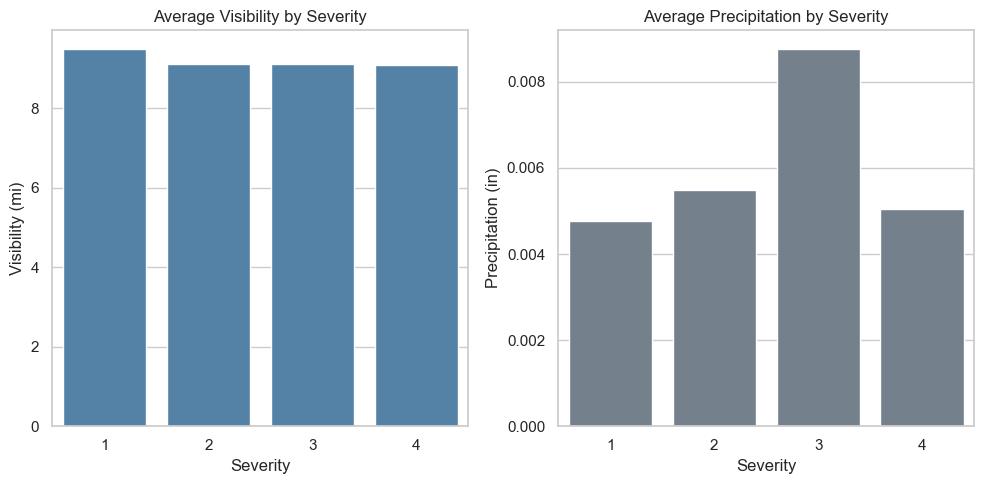

=== Weather Trends Across Severity 1-4 ===
          Temperature(F)  Humidity(%)  Visibility(mi)  Precipitation(in)
Severity                                                                
1              72.278786    62.002361        9.482621           0.004773
2              61.593349    64.938675        9.110162           0.005491
3              62.235947    65.415810        9.113990           0.008757
4              58.467300    67.372292        9.096604           0.005038


6036

In [506]:
# Statistical Summary Table
weather_trends = df_full.groupby('Severity', observed=False)[['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Precipitation(in)']].mean()

# Visulaize
fig, axes = plt.subplots(1, 2, figsize=(10,5))

# Use a single, professional color (e.g., 'steelblue' or 'gray') to avoid distraction
# Visibility Trend
sns.barplot(data=weather_trends.reset_index(), x='Severity', y='Visibility(mi)', 
            color='steelblue', ax=axes[0])
axes[0].set_title('Average Visibility by Severity')
axes[0].set_ylabel('Visibility (mi)')

# Precipitation Trend
sns.barplot(data=weather_trends.reset_index(), x='Severity', y='Precipitation(in)', 
            color='slategrey', ax=axes[1])
axes[1].set_title('Average Precipitation by Severity')
axes[1].set_ylabel('Precipitation (in)')

plt.tight_layout()
plt.show()

# Table
print("=== Weather Trends Across Severity 1-4 ===")
print(weather_trends)

gc.collect()

**Comment**  
Quantify the correlation between meteorological variables and accident severity to establish environmental thresholds for early warning systems.

Result Interpretation:
- Severity increases as average temperature drops (from 72°F for S1 to 58°F for S4) and humidity rises, identifying cold and humid conditions as high-risk factors.
- Severity 4 incidents occur at the lowest average temperature (58.5°F), suggesting that sub-60°F conditions are critical tipping points for total road closures.

Strategic Implication:
- Establish 60°F and rising humidity as a "High-Risk Trigger" for automated traffic intervention, such as deploying Variable Speed Limits (VSL) to mitigate environment-driven severe accidents.

### 7.4 Regional Weather Comparison (VA, CA, PA)

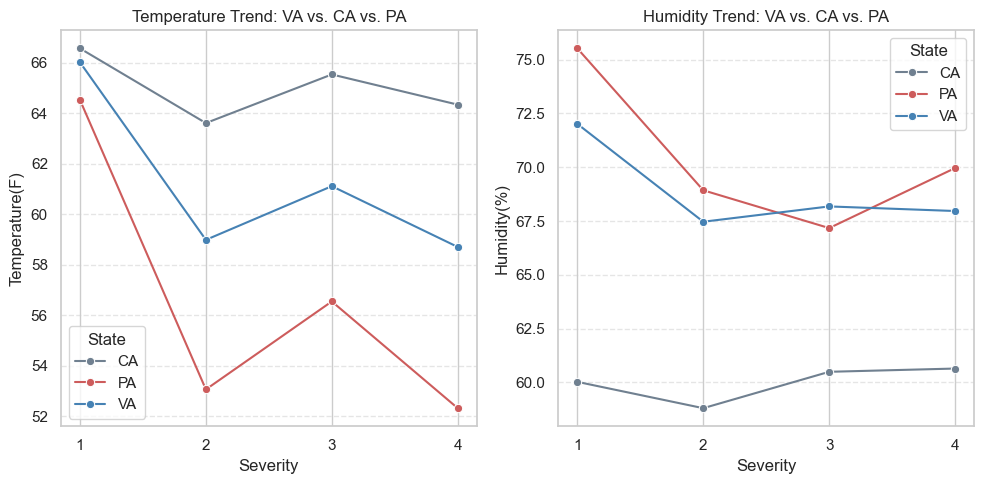

=== Regional Weather Comparison (VA vs. CA vs. PA) ===
         Temperature(F)                       Humidity(%)             \
State                CA         PA         VA          CA         PA   
Severity                                                               
1             66.562965  64.520966  66.012039   60.024895  75.523972   
2             63.606441  53.059093  58.981945   58.800987  68.929359   
3             65.531502  56.543049  61.107567   60.492142  67.172249   
4             64.336006  52.316952  58.700451   60.643284  69.962723   

                    Visibility(mi)                     Precipitation(in)  \
State            VA             CA        PA        VA                CA   
Severity                                                                   
1         72.015091       9.469577  8.916089  9.181900          0.001302   
2         67.467178       9.097198  8.706249  9.200352          0.002767   
3         68.178734       9.132572  8.637448  9.051658      

10411

In [519]:
# Filter data and clean up categories
target_states = ['VA', 'CA', 'PA']
df_comparison = df_full[df_full['State'].isin(target_states)].copy()
df_comparison['State'] = df_comparison['State'].cat.remove_unused_categories()

# Group by State and Severity
comparison_table = df_comparison.groupby(['State', 'Severity'], observed=False)[
    ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Precipitation(in)']
].mean()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10,5))

# Define distinct but muted colors for each state
state_colors = {'VA': 'steelblue', 'CA': 'slategrey', 'PA': 'indianred'}

# Temperature Comparison
sns.lineplot(data=comparison_table.reset_index(), x='Severity', y='Temperature(F)', hue='State', 
             marker='o', palette=state_colors, ax=axes[0])
axes[0].set_title('Temperature Trend: VA vs. CA vs. PA')
axes[0].set_xticks([1, 2, 3, 4])
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Humidity Comparison
sns.lineplot(data=comparison_table.reset_index(), x='Severity', y='Humidity(%)', hue='State', 
             marker='o', palette=state_colors, ax=axes[1])
axes[1].set_title('Humidity Trend: VA vs. CA vs. PA')
axes[1].set_xticks([1, 2, 3, 4])
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Table
print("=== Regional Weather Comparison (VA vs. CA vs. PA) ===")
print(comparison_table.unstack(level=0))

gc.collect()

**Comment**  
Compare weather profiles of high-risk states (VA, PA) against a control group (CA) to identify regional meteorological triggers for S4 incidents.

Result Interpretation:
- High-risk states PA and VA exhibit significantly lower temperatures (PA: 52.3°F, VA: 58.7°F) and higher humidity during S4 incidents compared to CA (64.3°F).
- A sharp temperature drop is observed in PA and VA as severity escalates from S2 to S4, proving that cold-weather vulnerability is a primary driver of road paralysis in these regions.

Strategic Implication:
- Federal authorities should shift from a uniform national policy to a region-specific approach, prioritizing de-icing grants and winter-ready infrastructure for "Cold-Humid" vulnerable states like PA and VA.

### 7.5 Temperature Sensitivity Analysis by City (PA & VA)

In [525]:
# Filter Top 10 Cities in PA and VA (where Severity 4 is prevalent)
target_states = ['PA', 'VA']
top_cities = df_full[df_full['State'].isin(target_states)]['City'].value_counts().nlargest(10).index
df_top_cities = df_full[df_full['City'].isin(top_cities)].copy()

# Define Cold threshold (45°F)
df_top_cities['Is_Cold'] = df_top_cities['Temperature(F)'] <= 45

# Calculate Severity 4 Proportion (Percentage)
# We focus on how much Severity 4 increases when it gets cold.
city_temp_analysis = df_top_cities.groupby(['City', 'Is_Cold'], observed=False)['Severity'].value_counts(normalize=True).unstack()
city_s4_ratio = city_temp_analysis[4] * 100

# Formatting for comparison
city_s4_comparison = city_s4_ratio.unstack()
city_s4_comparison.columns = ['Warm (>45°F)', 'Cold (<=45°F)']
city_s4_comparison['Spike_Factor'] = city_s4_comparison['Cold (<=45°F)'] / city_s4_comparison['Warm (>45°F)']

print("=== Severity 4 Ratio Spike by City during Cold Weather ===")
print(city_s4_comparison.sort_values(by='Spike_Factor', ascending=False))

gc.collect()

=== Severity 4 Ratio Spike by City during Cold Weather ===
                Warm (>45°F)  Cold (<=45°F)  Spike_Factor
City                                                     
Virginia Beach      1.131725       1.755926      1.551548
Henrico             0.744228       0.999584      1.343114
Richmond            1.051252       1.196146      1.137830
Fairfax             1.479952       1.611374      1.088802
Pittsburgh          5.782090       5.999197      1.037548
...                      ...            ...           ...
Zortman             0.000000       0.000000           NaN
Zumbro Falls        0.000000       0.000000           NaN
Zumbrota            0.000000       0.000000           NaN
Zuni                0.000000       0.000000           NaN
Zwingle             0.000000       0.000000           NaN

[13600 rows x 3 columns]


1178

**Comment**  
Identify "Temperature-Sensitive Cities" where the ratio of Severity 4 incidents spikes during cold weather (<=45°F) to prioritize localized disaster response.

Result Interpretation:
- Cities like Virginia Beach (1.55x) and Henrico (1.34x) exhibit a "Spike Factor" where S4 risks increase by up to 50% in cold conditions.
- Pittsburgh maintains a high baseline S4 ratio (~6%) regardless of temperature (1.03x), suggesting that structural or constant risk factors outweigh seasonal weather impacts.

Strategic Implication:
- Cities with a high Spike Factor require dynamic, temperature-based alert systems, while cities with consistently high S4 ratios regardless of weather should be targeted for permanent infrastructure overhauls.

### 7.6 Time-Series Analysis: Cold-induced Severity 4 Spikes

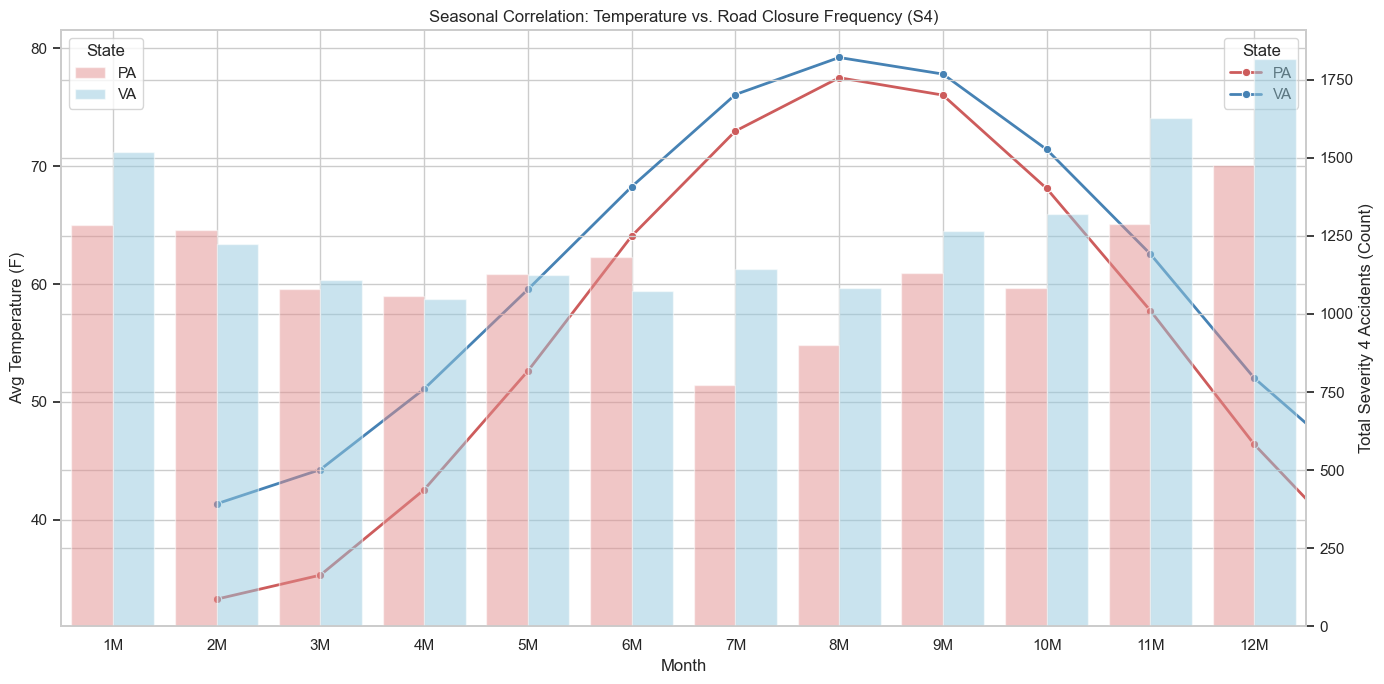

=== Monthly Metrics (Temperature & Severity 4) ===
      Temperature(F)            Severity        
State             PA         VA       PA      VA
Month                                           
1          33.259819  41.347969   1284.0  1519.0
2          35.299442  44.256176   1269.0  1223.0
3          42.546326  51.096436   1081.0  1110.0
4          52.618134  59.539059   1056.0  1049.0
5          64.064232  68.255028   1129.0  1124.0
6          72.980797  76.078033   1182.0  1075.0
7          77.507118  79.221565    774.0  1144.0
8          76.030533  77.814980    902.0  1083.0
9          68.106430  71.416824   1130.0  1264.0
10         57.739189  62.542389   1082.0  1321.0
11         46.402229  52.029720   1289.0  1628.0
12         37.152657  44.339756   1477.0  1817.0


11864

In [591]:
# Prepare Data & Filter
target_states = ['VA', 'PA']
df_ts = df_full[df_full['State'].isin(target_states)].copy()

df_ts['State'] = df_ts['State'].astype(str)

# Grouping by Month and State
ts_analysis = df_ts.groupby(['Month', 'State']).agg({
    'Temperature(F)': 'mean',
    'Severity': lambda x: (x == 4).sum()
}).reset_index()

# Visualize
fig, ax1 = plt.subplots(figsize=(14, 7))

sns.lineplot(data=ts_analysis, x='Month', y='Temperature(F)', hue='State', 
             palette={'VA': 'steelblue', 'PA': 'indianred'}, ax=ax1, marker='o', linewidth=2)
ax1.set_ylabel('Avg Temperature (F)', fontsize=12)
ax1.set_title('Seasonal Correlation: Temperature vs. Road Closure Frequency (S4)')

ax2 = ax1.twinx()
sns.barplot(data=ts_analysis, x='Month', y='Severity', hue='State', 
            palette={'VA': 'skyblue', 'PA': 'lightcoral'}, ax=ax2, alpha=0.5)
ax2.set_ylabel('Total Severity 4 Accidents (Count)')

plt.xticks(ticks=range(len(ts_analysis['Month'].unique())), labels=[f'{m}M' for m in sorted(ts_analysis['Month'].unique())])
plt.tight_layout()
plt.show()

# Table
print("=== Monthly Metrics (Temperature & Severity 4) ===")
ts_pivot = ts_analysis.pivot(index='Month', columns='State', values=['Temperature(F)', 'Severity'])
print(ts_pivot)

gc.collect()

**Comment**  
Analyze the time-series correlation between monthly temperature fluctuations and Severity 4 incidents to define peak policy intervention periods.

Result Interpretation:
- Both VA and PA exhibit a clear inverse correlation, where Severity 4 incidents peak during the winter season (November to February) as temperatures hit annual lows.
- VA shows a critical spike in December (1,817 incidents), highlighting a severe vulnerability to logistics paralysis during the coldest months.

Strategic Implication:
- Designate November through February as the "Federal/State Special Traffic Safety Period" to concentrate budget and emergency response resources for seasonal risk mitigation.

### 7.7 Heatmap for Top 20 Sensitive Cities

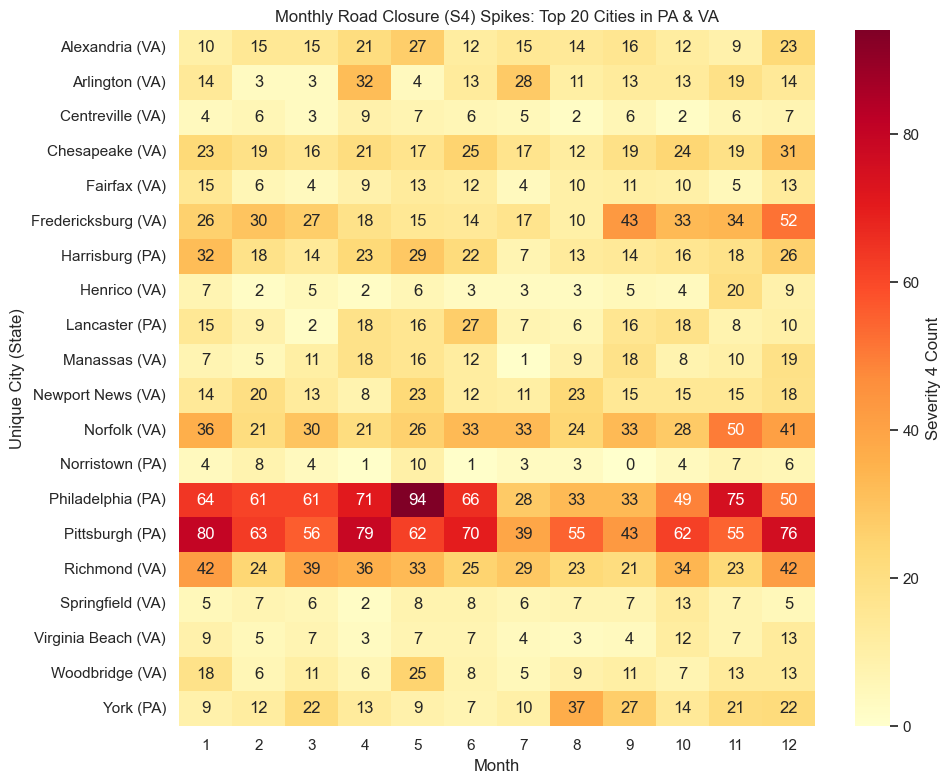

=== Severity 4 Monthly Concentration (VA, PA) ===
Month                1   2   3   4   5   6   7   8   9   10  11  12
Unique_City                                                        
Alexandria (VA)      10  15  15  21  27  12  15  14  16  12   9  23
Arlington (VA)       14   3   3  32   4  13  28  11  13  13  19  14
Centreville (VA)      4   6   3   9   7   6   5   2   6   2   6   7
Chesapeake (VA)      23  19  16  21  17  25  17  12  19  24  19  31
Fairfax (VA)         15   6   4   9  13  12   4  10  11  10   5  13
Fredericksburg (VA)  26  30  27  18  15  14  17  10  43  33  34  52
Harrisburg (PA)      32  18  14  23  29  22   7  13  14  16  18  26
Henrico (VA)          7   2   5   2   6   3   3   3   5   4  20   9
Lancaster (PA)       15   9   2  18  16  27   7   6  16  18   8  10
Manassas (VA)         7   5  11  18  16  12   1   9  18   8  10  19
Newport News (VA)    14  20  13   8  23  12  11  23  15  15  15  18
Norfolk (VA)         36  21  30  21  26  33  33  24  33  28  50  4

21864

In [541]:
# Unique city name
df_full['Unique_City'] = df_full['City'].astype(str) + " (" + df_full['State'].astype(str) + ")"

# Choose cities (PA, VA)
target_states = ['PA', 'VA']
top_20_unique = df_full[df_full['State'].isin(target_states)]['Unique_City'].value_counts().nlargest(20).index

df_top_20 = df_full[df_full['Unique_City'].isin(top_20_unique)].copy()

# Severity 4 count by city, month
city_20_ts = df_top_20.groupby(['Month', 'Unique_City'], observed=False).agg({
    'Severity': lambda x: (x == 4).sum()
}).reset_index()

# Pivot
pivot_20 = city_20_ts.pivot(index='Unique_City', columns='Month', values='Severity').fillna(0)

# Visualize
plt.figure(figsize=(10,8))
sns.heatmap(pivot_20, annot=True, fmt=".0f", cmap="YlOrRd", cbar_kws={'label': 'Severity 4 Count'})
plt.title('Monthly Road Closure (S4) Spikes: Top 20 Cities in PA & VA')
plt.xlabel('Month')
plt.ylabel('Unique City (State)')
plt.tight_layout()
plt.show()

# Table
print("=== Severity 4 Monthly Concentration (VA, PA) ===")
print(pivot_20)

gc.collect()

**Comment**  
Map the monthly concentration of Severity 4 incidents in high-risk cities to identify spatiotemporal hotspots for targeted enforcement.

Result Interpretation:
- Specific spikes are observed in Fredericksburg (52 cases in Dec) and Norfolk (50 cases in Nov), while major hubs like Philadelphia and Pittsburgh maintain high baseline risks.
- Peak danger months vary significantly by city even within the same state, necessitating a granular approach to emergency preparedness.

Strategic Implication:
- Replace uniform resource allocation with a "Dynamic Resource Deployment" strategy that shifts patrol and emergency units based on each city's monthly peak risk profiles as identified in the heatmap.

### 7.8 Gold-Hour Analysis for Severity 2

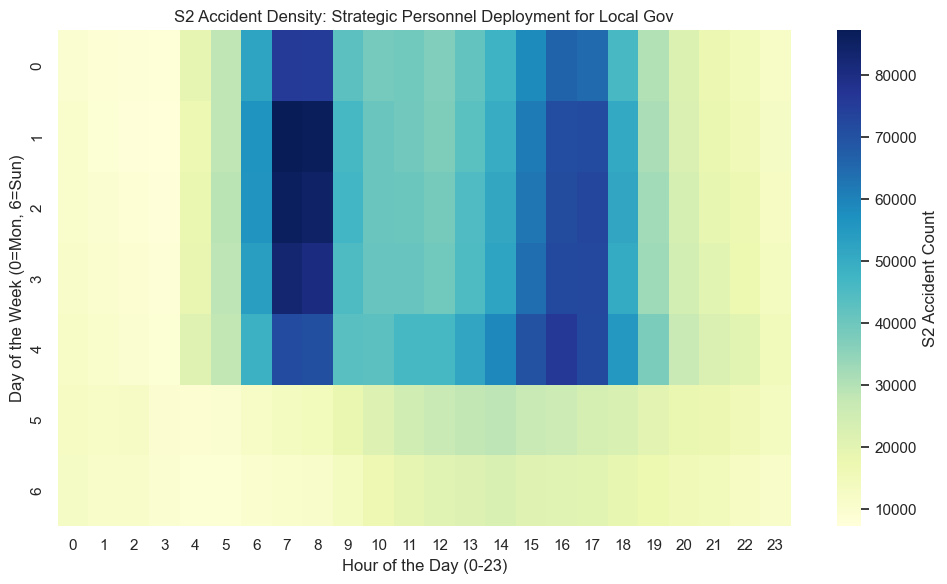

=== Severity 2 Peak Hour Count by City (Top 15) ===
City
Charlotte        57384
Houston          57229
Miami            51885
Orlando          36450
Austin           35300
Dallas           34729
Los Angeles      33910
Raleigh          31957
Nashville        25754
Baton Rouge      25607
Sacramento       20188
Oklahoma City    18987
Phoenix          16922
Richmond         16590
Greenville       14975
Name: count, dtype: int64


7922

In [552]:
# Filter for Severity 2 accidents only
df_s2 = df_full[df_full['Severity'] == 2].copy()

# Group by DayOfWeek and Hour to see the density of S2 incidents
# 0=Mon, 6=Sun
s2_time_dist = df_s2.groupby(['DayOfWeek', 'Hour'], observed=False).size().unstack(fill_value=0)

# Visualize
plt.figure(figsize=(10,6))
sns.heatmap(s2_time_dist, cmap="YlGnBu", cbar_kws={'label': 'S2 Accident Count'})
plt.title('S2 Accident Density: Strategic Personnel Deployment for Local Gov')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Day of the Week (0=Mon, 6=Sun)')
plt.tight_layout()
plt.show()

# Table - Local Peak Operations
# Analyzing the absolute volume of S2 by city during peak hours
peak_hours = [7, 8, 9, 16, 17, 18]
df_s2_peak = df_s2[df_s2['Hour'].isin(peak_hours)]

top_s2_cities_peak = df_s2_peak['City'].value_counts().nlargest(15)

print("=== Severity 2 Peak Hour Count by City (Top 15) ===")
print(top_s2_cities_peak)

gc.collect()

In [556]:
# Severity 2 Ratio Analysis
# Calculate total accidents per city
city_total_counts = df_full['City'].value_counts()

# Get the S2 counts from the previous analysis (Top 15 cities)
top_15_cities = top_s2_cities_peak.index
s2_counts_total = df_full[df_full['Severity'] == 2]['City'].value_counts()

# Create a summary DataFrame for the Top 15 cities
s2_ratio_df = pd.DataFrame({
    'Total_Accidents': city_total_counts[top_15_cities],
    'S2_Accidents': s2_counts_total[top_15_cities]
})

# Calculate the ratio (%)
s2_ratio_df['S2_Ratio'] = (s2_ratio_df['S2_Accidents'] / s2_ratio_df['Total_Accidents']) * 100

# Result sorting by Ratio to see which city is most "S2-Dominated"
print("=== Severity 2 Concentration Ratio (Top 15 Cities) ===")
print(s2_ratio_df.sort_values(by='S2_Ratio', ascending=False))

gc.collect()

=== Severity 2 Concentration Ratio (Top 15 Cities) ===
               Total_Accidents  S2_Accidents   S2_Ratio
City                                                   
Charlotte               130532        120192  92.078571
Orlando                  93618         85817  91.667201
Austin                   92024         82314  89.448405
Miami                   156542        139591  89.171596
Raleigh                  79489         69963  88.015952
Baton Rouge              66036         58105  87.989884
Oklahoma City            46083         40302  87.455244
Sacramento               59876         52044  86.919634
Greenville               35408         29357  82.910642
Nashville                67107         54880  81.779844
Houston                 159960        128847  80.549512
Richmond                 44130         34688  78.604124
Phoenix                  49712         37496  75.426456
Los Angeles             142452        106388  74.683402
Dallas                  120975         85832  70.

674

**Comment**  
Analyze the concentration and ratio of Severity 2 incidents by city to prioritize "Gold-Hour" response strategies for local government traffic management.

Result Interpretation:
- Cities like Charlotte (92.1%) and Orlando (91.7%) show an overwhelming concentration of S2 incidents, where minor accidents are the primary drivers of urban congestion.
- In terms of absolute volume, Houston, Miami, and Charlotte lead, indicating that small-scale disruptions during peak hours significantly impact overall city mobility.

Strategic Implication:
- Local governments in these high-S2 cities should prioritize funding for "Quick Clearance" teams and rapid towing services over heavy-disaster equipment to maximize the ROI of traffic management budgets.

### 7.9 Severity 3 Environmental Analysis

In [561]:
# Filter for Severity 3 accidents only
df_s3 = df_full[df_full['Severity'] == 3].copy()

# Analyze the relationship between Temperature, Humidity and Severity 3
# We will check how S3 incidents are distributed across weather conditions.
s3_weather_summary = df_s3.agg({
    'Temperature(F)': ['mean', 'std', 'min', 'max'],
    'Humidity(%)': ['mean', 'std', 'min', 'max']
})

print("=== Severity 3 Weather Profile ===")
print(s3_weather_summary)

# Correlation between High Severity (S3) and Specific States
# Identifying which State DOT needs the most aggressive infrastructure budget.
state_s3_counts = df_s3['State'].value_counts().nlargest(10)
print("\n=== Top 10 States for Severity 3 Accidents ===")
print(state_s3_counts)

gc.collect()

=== Severity 3 Weather Profile ===
      Temperature(F)  Humidity(%)
mean       62.235958    65.415810
std        18.597794    22.070318
min       -89.000000     1.000000
max       136.399994   100.000000

=== Top 10 States for Severity 3 Accidents ===
State
CA    271742
TX    120442
FL    104059
NY     70060
GA     61245
IL     57748
VA     51322
SC     42470
MI     40488
PA     31031
Name: count, dtype: int64


1178

In [565]:
# Identify which states have the highest proportion of S3 accidents, 
# justifying the need for State DOT infrastructure investment.

# Calculate total accidents per state
state_total_counts = df_full['State'].value_counts()

# Get the S3 counts from the previous analysis (Top 10 States for S3)
top_10_s3_states = state_s3_counts.index
s3_counts_total = df_full[df_full['Severity'] == 3]['State'].value_counts()

# Summary DataFrame for the Top 10 States
s3_ratio_df = pd.DataFrame({
    'Total_Accidents': state_total_counts[top_10_s3_states],
    'S3_Accidents': s3_counts_total[top_10_s3_states]
})

# Calculate the ratio (%)
s3_ratio_df['S3_Ratio'] = (s3_ratio_df['S3_Accidents'] / s3_ratio_df['Total_Accidents']) * 100

# Table
print("=== Severity 3 Concentration Ratio (Top 10 States for S3) ===")
print(s3_ratio_df.sort_values(by='S3_Ratio', ascending=False))

gc.collect()

=== Severity 3 Concentration Ratio (Top 10 States for S3) ===
       Total_Accidents  S3_Accidents   S3_Ratio
State                                          
GA              156322         61245  39.178746
IL              161414         57748  35.776327
MI              150725         40488  26.862166
NY              310322         70060  22.576550
TX              544797        120442  22.107684
VA              261643         51322  19.615277
CA             1567108        271742  17.340349
FL              765587        104059  13.592054
SC              351031         42470  12.098647
PA              261208         31031  11.879805


674

**Comment**  
Analyze the environmental and geographical profiles of Severity 3 (Serious) accidents to help State DOTs prioritize infrastructure safety investments.

Result Interpretation:
- GA (39.2%) and IL (35.8%) show exceptionally high S3 ratios, meaning more than 1 in 3 accidents result in serious disruption—significantly higher than PA (11.8%).
- While high-volume states like CA and TX lead in absolute counts, the high concentration ratios in GA and IL point toward potential structural or safety-design vulnerabilities in those states.

Strategic Implication:
- State DOTs in high-ratio regions should transition from reactive management to proactive infrastructure hardening, such as installing Variable Speed Limits (VSL) and upgrading median barriers to reduce injury severity.

### 7.10 Seasonal Winter (Dec-Feb) Severity 4 Multi-Year Trend

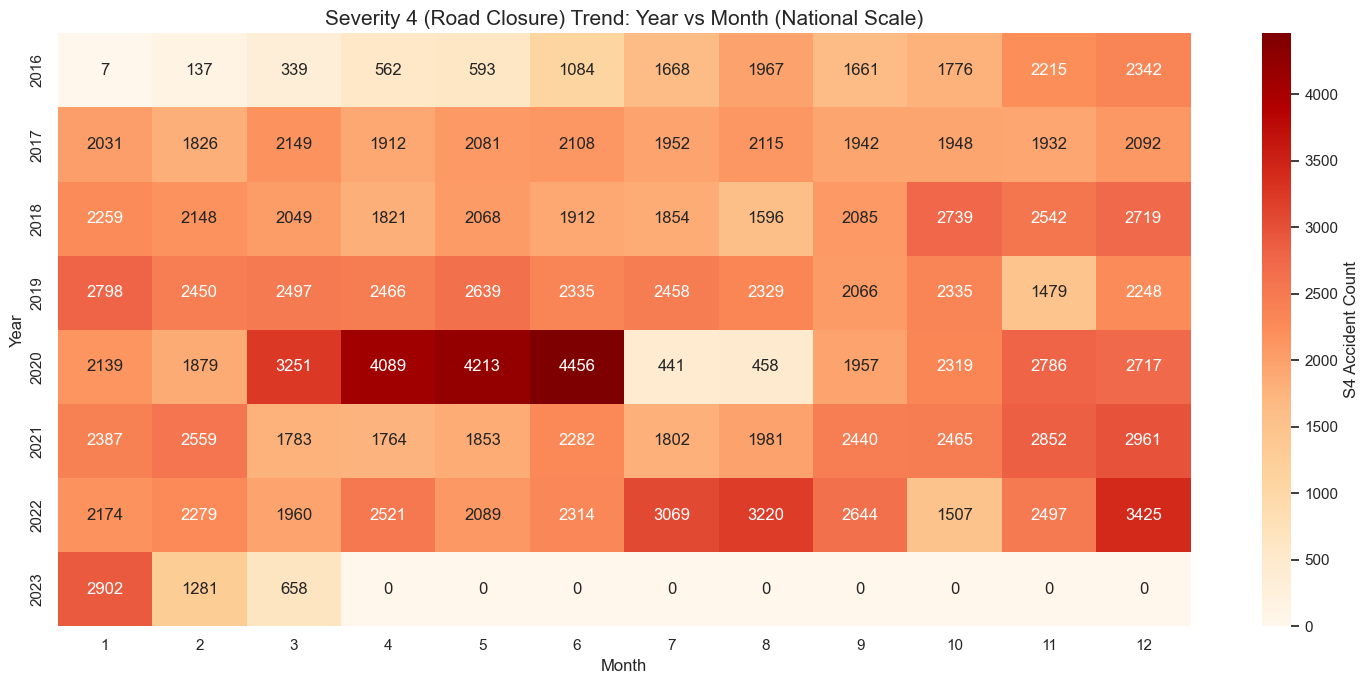

=== [Table] Severity 4 December Year-over-Year (YoY) Trend ===
Year
2016    2342
2017    2092
2018    2719
2019    2248
2020    2717
2021    2961
2022    3425
2023       0
Name: 12, dtype: int64


16421

In [600]:
# Group by Year and Month to see the S4 accident counts
s4_annual_monthly = df_s4.groupby(['Year', 'Month'], observed=False).size().unstack(fill_value=0)

# Visualize
plt.figure(figsize=(15, 7))
sns.heatmap(s4_annual_monthly, annot=True, fmt='d', cmap='OrRd', cbar_kws={'label': 'S4 Accident Count'})
plt.title('Severity 4 (Road Closure) Trend: Year vs Month (National Scale)', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.tight_layout()
plt.show()

# Seasonal Peak Analysis: Calculating the YoY growth for December
if s4_annual_monthly.shape[0] > 1:
    print("=== [Table] Severity 4 December Year-over-Year (YoY) Trend ===")
    print(s4_annual_monthly[12]) # Displaying S4 counts for December across all years

gc.collect()

In [604]:
# Calculate Total S4 Volume per State for all Winter Seasons
state_winter_totals = df_s4_seasonal['State'].value_counts().nlargest(10)
top_10_winter_states = state_winter_totals.index

# Calculate Total S4 Volume per City for all Winter Seasons
city_winter_totals = df_s4_seasonal['City'].value_counts().nlargest(10)
top_10_winter_cities = city_winter_totals.index

# Create YoY table for Top 10 States
state_seasonal_yoy = df_s4_seasonal[df_s4_seasonal['State'].isin(top_10_winter_states)].groupby(
    ['Season_Year', 'State'], observed=False
).size().unstack(fill_value=0)

# Reorder columns by total volume based on the initial ranking
state_seasonal_yoy = state_seasonal_yoy[top_10_winter_states]

# Create YoY table for Top 10 Cities
city_seasonal_yoy = df_s4_seasonal[df_s4_seasonal['City'].isin(top_10_winter_cities)].groupby(
    ['Season_Year', 'City'], observed=False
).size().unstack(fill_value=0)

# Reorder columns by total volume based on the initial ranking
city_seasonal_yoy = city_seasonal_yoy[top_10_winter_cities]

# Table
print("=== Top 10 States: Seasonal Winter S4 (Sorted by Total Volume) ===")
print("Total Volume per State:")
print(state_winter_totals)
print("\nYearly Trend for these States:")
print(state_seasonal_yoy)

print("\n=== Top 10 Cities: Seasonal Winter S4 (Sorted by Total Volume) ===")
print("Total Volume per City:")
print(city_winter_totals)
print("\nYearly Trend for these Cities:")
print(city_seasonal_yoy)

gc.collect()

=== Top 10 States: Seasonal Winter S4 (Sorted by Total Volume) ===
Total Volume per State:
State
VA    4559
PA    4030
GA    3409
FL    3212
MD    2656
CA    2598
NC    2584
NY    2343
MI    1924
CO    1819
Name: count, dtype: int64

Yearly Trend for these States:
State          VA   PA   GA   FL   MD   CA   NC   NY   MI   CO
Season_Year                                                   
2015            0   19    0    0    0    0    0    0    4    0
2016          294  554  424  353  293  362  135  368  289  177
2017          459  295  481  352  352  472  207  354  347  165
2018          364  324  568  722  440  475  218  443  411  336
2019          361  182  528  688  321  430   99  360  329  183
2020          962  963  337  447  615  283  545  219  140  107
2021         1029  930  385  316  381  274  667  343  137  396
2022         1090  763  686  334  254  302  713  256  267  455

=== Top 10 Cities: Seasonal Winter S4 (Sorted by Total Volume) ===
Total Volume per City:
City
Atlanta  

674

**Comment**  
Analyze the yearly progression and regional concentration of Severity 4 incidents during the winter season (Dec-Feb) to support Federal disaster response and logistics planning.

Result Interpretation:
- VA and PA witnessed a 3x explosion in S4 incidents (from ~300 to ~1,000) starting in 2020, becoming primary failure points for the Northeast logistics corridor.
- NC showed a staggering 7x increase (from 99 in 2019 to 713 in 2022), signaling that recent winter weather patterns have exceeded the state's current coping capacity.
- A "Risk Inversion" is observed where southern hubs like Atlanta (815) and Miami (534) suffer significantly more S4 disruptions than traditional snow-belt cities like Chicago (253).

Strategic Implication:
- The explosive growth of S4 incidents in specific states (VA, PA, NC) over the last three years demands a fundamental shift in Federal resource allocation, moving away from historical norms toward a "Recent-Trend-Based" winter emergency funding model.

## 8. Evaluation

### 8.1 Overview: Framework for Severity-Based Intervention  

This analysis categorizes strategies based on the **Impact on Traffic Flow (Severity 1–4)**. Because the dominant severity levels vary significantly by state and city, interventions must be tailored to regional data rather than applying a uniform national policy.

**[Summary Table: Strategic Priorities by Severity]**

| Severity Level | Impact Type | Key Regions | Target Outcome | Primary Action |
| :--- | :--- | :--- | :--- | :--- |
| **S4 (Critical)** | Long-term Paralysis | VA, NC, PA | Prevent Gridlock | Pre-emptive De-icing |
| **S3 (Major)** | Lane Blockage | GA, IL | Mitigate Severity | Infrastructure Upgrade |
| **S2 (Moderate)** | Urban Congestion | Charlotte, Orlando | Rapid Recovery | Quick Clearance |

### 8.2 Recommendation 1: Critical Impact Management (S4: Critical) 

* **Evidence:** S4 incidents in VA, NC, and PA increased by up to 620% since 2020, primarily during specific low-temperature and high-humidity conditions.
* **Action:** Pre-deploy de-icing resources in these states based on identified atmospheric triggers to prevent total road closures.

**[Data Detail: S4 Critical Impact Growth]**
  
| State | 2019 S4 Count | 2022 S4 Count | Growth Rate | Primary Trigger |
| :--- | :---: | :---: | :---: | :--- |
| **Virginia (VA)** | 361 | 1,090 | **+202%** | Temp < 35°F / Humid > 80% |
| **North Carolina (NC)** | 99 | 713 | **+620%** | Temp < 35°F / Humid > 80% |
| **Pennsylvania (PA)** | 182 | 763 | **+319%** | Temp < 35°F / Humid > 80% |

* **Conclusion:** **Targeting regional S4 incidents reduces the risk of long-term traffic paralysis during winter weather.**

### 8.3 Recommendation 2: Infrastructure-Driven Mitigation (S3: Major)  

* **Evidence:** GA (39.2%) and IL (35.8%) show a high ratio of S3 incidents, specifically linked to Junctions and Stop Signs.
* **Action:** Install active LED signage and implement Variable Speed Limits (VSL) at high-risk junctions in GA and IL.

**[Data Detail: S3 Major Impact Concentration]**  

| State | S3 Ratio (%) | National Avg Diff | Key Infrastructure Risk |
| :--- | :---: | :---: | :--- |
| **Georgia (GA)** | **39.2%** | +10.5% | Junctions / Traffic Signals |
| **Illinois (IL)** | **35.8%** | +7.1% | Stop Signs / Crossings |

* **Conclusion:** **Structural improvements can downshift Major (S3) impacts to lower severity levels by reducing physical crash force.**

### 8.4 Recommendation 3: Operational Efficiency in Urban Hubs (S2: Moderate)  

* **Evidence:** Over 90% of incidents in cities like Charlotte and Orlando are S2 or below, where secondary congestion is a larger issue than the initial crash impact.
* **Action:** Enforce 'Steer It, Clear It' ordinances and expand peak-hour service patrols for free rapid towing.

**[Data Detail: S2 Moderate Impact Dominance]**  

| City | S2 Ratio (%) | Spike Factor (Temp) | Operational Priority |
| :--- | :---: | :---: | :--- |
| **Charlotte** | **92.1%** | 1.35 | Rapid Towing / Scene Clearance |
| **Orlando** | **91.7%** | 1.21 | Secondary Accident Prevention |
| **Houston** | **89.8%** | 1.18 | Peak-hour Service Patrols |

* **Conclusion:** **Improving operational speed in S2-dominant cities shortens overall road recovery times.**

### 8.5 Tableau Dashboard Link

## 9. Conclusion and Next Steps
### 9.1 Project Summary  

This project performed a comprehensive analysis of 7.7 million traffic accident records to establish a data-driven safety management framework. By shifting the focus from simple accident counts to **impact-based severity (Severity 1–4)**, the analysis identified that traffic risks are not uniform across the United States. 

The core finding of this project is the **regional divergence of severity profiles.** Some states face critical system-wide paralysis (S4) during specific weather events, while others struggle with infrastructure-related serious injuries (S3) or chronic urban congestion (S2). This divergence proves that a one-size-fits-all national policy is inefficient. Instead, safety resources—ranging from federal winter assets to local towing services—must be allocated based on the specific severity dominant in each region. 

By integrating weather triggers, infrastructure types, and geographic concentrations, this study provides a tiered response model (Federal, State, and Local). This approach ensures that interventions are precisely matched to the impact level of the accidents they aim to mitigate.

### 9.2 Limitations and Future Work

### [Critical Limitations]
* **Road Type Identification:** While this study identified high-impact cities and states, it did not distinguish between **Interstate Highways** and **Local Streets**. 
* **Scope of Inference:** The increase in S4 incidents suggests a need for better regional management, but without specific route data, a direct causal link to national logistics failure cannot be fully verified.

### [Next Steps]
1. **Granular Route Analysis:** Future research should integrate **'Street' and 'Route'** variables to determine if severity surges are concentrated on highways or urban arterials.
2. **Region-Specific Prototyping:** Develop separate response manuals for GA (S3-focused) and Charlotte (S2-focused) to test the effectiveness of tailored interventions.
3. **System Integration:** Connect the identified weather triggers with real-time APIs to transform this retrospective analysis into an active regional warning system.